In [44]:
from typing import NamedTuple
import math
import matplotlib.pyplot as plt

In [45]:
class Claim(NamedTuple):
    label: str
    description: str
    prior: float
    fde: float


The claims

C1
: There is a family of elephants living in the refrigerator in my kitchen.

C2
: There are some stars with planets orbiting them in the galaxy BX422.

C3
: There is a forth planet around the millionth brightest star in BX422 on which there is a family of African elephants living in a refrigerator.

C4
: Ignoring air resistance, a heavier object will fall faster than a lighter one.


Probabilities listed below anywhere near my true assessements,
they are designed for placement on the chart we are creating.

In [ ]:
c1 = Claim(label = "C1",
            description="There is a family of elephants living in"
              " the refrigerator in my kitchen,",
            prior = 0.05,
            fde = 0.95)
c2 = Claim(label = "C2",
            description="There are some stars with planets orbiting them in the galaxy BX422.",
            prior = 0.80,
            fde = 0.05)
c3 = Claim(label="C3",
           description="There is a forth planet around the millionth brightest"
             " star in BX422 on which there is a family of African elephants" 
             " living in a refrigerator.",
            prior = 0.01,
            fde = 0.01)

c4 = Claim(label="C4",
           description="Ignoring air resistance, a heavier object"
            " will fall faster than a lighter one.",
            prior = 0.9,
            fde = 0.99)


Now we see if I can manage Pandas dataframses


In [47]:
claims =  {c.label: c for c in [c1, c2, c3, c4]}
claims

{'C1': Claim(label='C1', description='There is a family of elephants living in the refrigerator in my kitchen,', prior=1e-06, fde=0.99),
 'C2': Claim(label='C2', description='There are some stars with planets orbiting them in the galaxy BX422.', prior=0.95, fde=5e-06),
 'C3': Claim(label='C3', description='There is a forth planet around the millionth brightest star in BX422 on which there is a family of African elephants living in a refrigerator.', prior=1e-09, fde=1e-08),
 'C4': Claim(label='C4', description='Ignoring air resistance, a heavier object will fall faster than a lighter one.', prior=0.9, fde=0.99)}

Our examples can have extreme probabilities (very close to zero or very close to 1), so a log scale
will be better at showing difference, but we need those to be in terms of distence from the mid points.

In [121]:
def rescale(x: float) -> float:
    sign = 1 if x > 0.5 else -1
    d_mid = 2.0 * abs(x - 0.5)
    assert d_mid <= 1.0
    assert d_mid >= 0.0
    # stretched = math.pow(d_mid, 5)
    stretched = d_mid
    return sign * stretched

## Now trying with pyplot

Based on [centered spines example](https://matplotlib.org/stable/gallery/spines/centered_spines_with_arrows.html)

C1: (-0.999998, 0.98)
C2: (0.8999999999999999, -0.99999)
C3: (-0.999999998, -0.99999998)
C4: (0.8, 0.98)


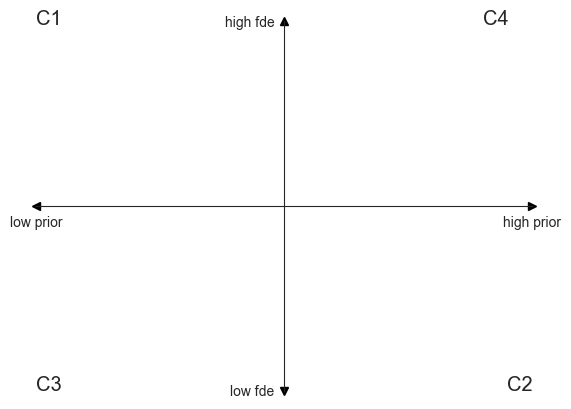

In [122]:
fig, ax = plt.subplots()
# Move the left and bottom spines to x = 0 and y = 0, respectively.
ax.spines[["left", "bottom"]].set_position(("data", 0))
# Hide the top and right spines.
ax.spines[["top", "right"]].set_visible(False)

# Draw arrows (as black triangles: ">k"/"^k") at the end of the axes.  In each
# case, one of the coordinates (0) is a data coordinate (i.e., y = 0 or x = 0,
# respectively) and the other one (1) is an axes coordinate (i.e., at the very
# right/top of the axes).  Also, disable clipping (clip_on=False) as the marker
# actually spills out of the Axes.
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 0, "<k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
ax.plot(0, 0, "vk", transform=ax.get_xaxis_transform(), clip_on=False)

# Some sample data.

for claim in claims.values():
  prior = rescale(claim.prior)
  fde = rescale(claim.fde)
  label = claim.label

  print(f"{label}: ({prior}, {fde})")

  plt.text(prior, fde, label, fontsize="x-large")
plt.xticks([-1, 1], ["low prior", "high prior"])
plt.yticks([-1, 1], ["low fde", "high fde"])


plt.show()